# Projekt në Modelime në Fizizkë
**Tema:** Personalized PageRank për një Rrjet Materialesh Kursi dhe Preferencash Tematike  
**Studenti:** Donaldo Shtjefni  
**Lënda:** Modelime në Fizikë  

---

## Hyrje e Shkurtër
Ky projekt modelon një rrjet materialesh akademike (nyje) dhe lidhjet midis tyre (linket). 
Qëllimi është të përdorim algoritmën **Personalized PageRank (PPR)** për të gjetur cilat materiale janë më të rëndësishme për një student, duke u bazuar në preferencat e tij specifike tematike (vektori i personalizimit $v$).

Në fizikën e sistemeve komplekse, kjo i korrespondon një "Random Walk" (ecje rastësore) me mundësi teleportimi drejt nyjeve të preferuara.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Përcaktimi i materialeve të kursit (Nyjet e rrjetit tonë)
nyjet = {
    0: "Mekanika Analitike",
    1: "Termodinamika",
    2: "Fizika Kvantike",
    3: "Metodat Matematikore",
    4: "Modelime në Fizikë"
}
N = len(nyjet)

# 2. Ndërtimi i Matricës së Adjacencës (Adjacency Matrix)
# A[i][j] = 1 tregon se ka një lidhje (link) nga nyja i tek nyja j
A = np.array([
    [0, 1, 0, 1, 0],  # Mekanika lidhet me Termodinamiken dhe Metodat Mat.
    [0, 0, 1, 0, 1],  # Termodinamika lidhet me Kvantiken dhe Modelimet
    [1, 0, 0, 0, 1],  # Kvantika lidhet me Mekaniken dhe Modelimet
    [1, 0, 0, 0, 1],  # Metodat Matematikore lidhen me Mekaniken dhe Modelimet
    [0, 1, 1, 0, 0]   # Modelimet lidhen me Termodinamiken dhe Kvantiken
], dtype=float)

print("Matrica e Adjacencës A:")
print(A)

Matrica e Adjacencës A:
[[0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [0. 1. 1. 0. 0.]]


In [3]:
# Ndërtojmë matricën e tranzicionit stastik M, ku shumat e rreshtave duhet të jenë 1
M = np.zeros_like(A)

for i in range(N):
    k_out = np.sum(A[i]) # Shkalla e daljes (out-degree)
    if k_out > 0:
        M[i] = A[i] / k_out
    else:
        M[i] = np.ones(N) / N # Nëse ka nyje pa rrugë daljeje (dangling node)

print("Matrica e Tranzicionit M (Probabilitetet e kalimit):")
print(M)

Matrica e Tranzicionit M (Probabilitetet e kalimit):
[[0.  0.5 0.  0.5 0. ]
 [0.  0.  0.5 0.  0.5]
 [0.5 0.  0.  0.  0.5]
 [0.5 0.  0.  0.  0.5]
 [0.  0.5 0.5 0.  0. ]]


In [10]:

def personalized_pagerank_me_histori(M, v, alpha=0.85, max_iter=20):
    N = M.shape[0]
    p = np.ones(N) / N
    historia = [p.copy()] # Ruajmë gjendjen fillestare
    
    for i in range(max_iter):
        p_next = alpha * np.dot(p, M) + (1 - alpha) * v
        historia.append(p_next.copy())
        p = p_next
        
    return p, np.array(historia)


In [11]:
# Supozojmë se studenti ka preferencë të lartë vetëm për "Fizika Kvantike" (Nyja 2)
v_kvantika = np.array([0.0, 0.0, 1.0, 0.0, 0.0]) 

pagerank_kvantika = personalized_pagerank(M, v_kvantika)

print("\nRezultatet e PPR (Fokusimi te Kvantika):")
for idx, score in enumerate(pagerank_kvantika):
    print(f"{nyjet[idx]}: {score:.4f}")

Algoritmi konvergoi pas 15 iteracionesh.

Rezultatet e PPR (Fokusimi te Kvantika):
Mekanika Analitike: 0.1715
Termodinamika: 0.1779
Fizika Kvantike: 0.3306
Metodat Matematikore: 0.0729
Modelime në Fizikë: 0.2471


In [12]:
# Supozojmë një preferencë të përzier: 50% Modelime (Nyja 4) dhe 50% Metodat Mat. (Nyja 3)
v_modelime = np.array([0.0, 0.0, 0.0, 0.5, 0.5]) 

pagerank_modelime = personalized_pagerank(M, v_modelime)

print("\nRezultatet e PPR (Fokusimi te Modelimet & Metodat):")
for idx, score in enumerate(pagerank_modelime):
    print(f"{nyjet[idx]}: {score:.4f}")

Algoritmi konvergoi pas 19 iteracionesh.

Rezultatet e PPR (Fokusimi te Modelimet & Metodat):
Mekanika Analitike: 0.1491
Termodinamika: 0.1936
Fizika Kvantike: 0.2125
Metodat Matematikore: 0.1384
Modelime në Fizikë: 0.3064


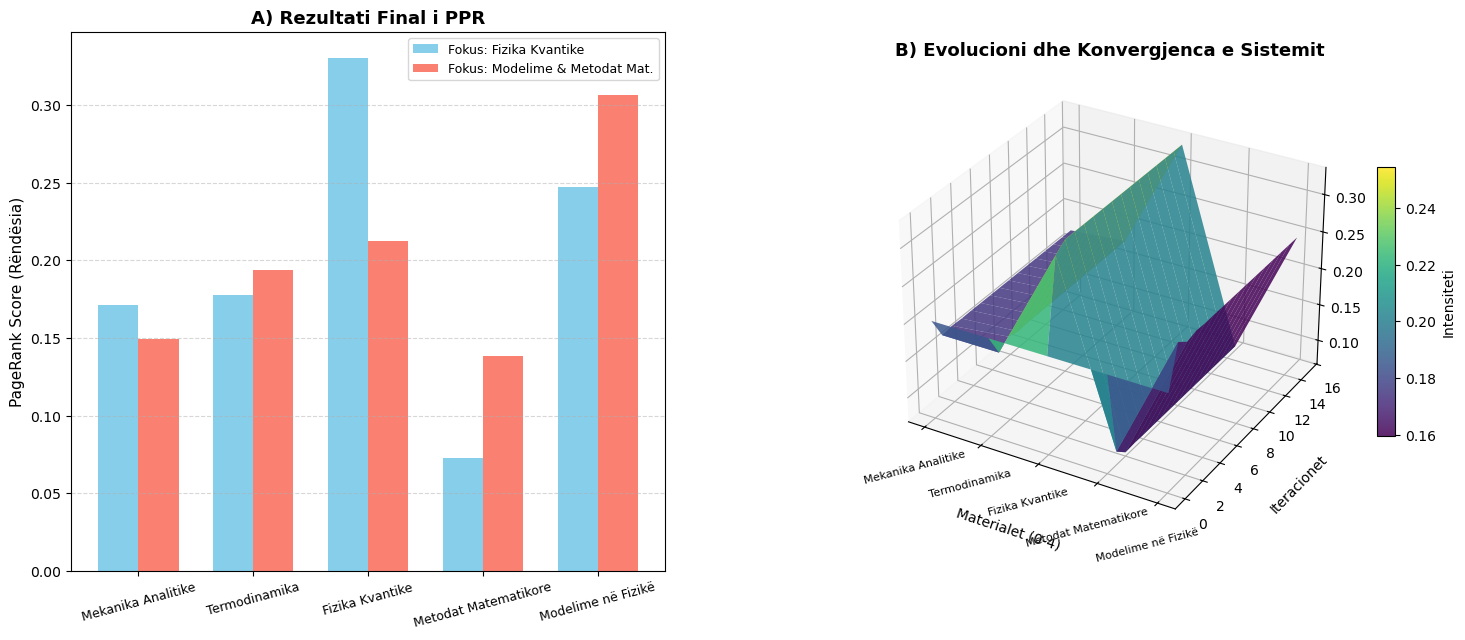

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Marrim të dhënat nga modeli për skenarin e parë (Fokus: Kvantika)
rezultati, historia = personalized_pagerank_me_histori(M, v_kvantika, max_iter=15)

# Krijojmë një figurë më të gjerë (18x7) që të ketë hapësirë të bollshme
fig = plt.figure(figsize=(18, 7))

# --- GRAFIKU 1 (MAJTAS): Grafiku me Shtylla (2D) ---
ax1 = fig.add_subplot(121)  # 1 rresht, 2 kolona, pozicioni 1

labels = [nyjet[i] for i in range(N)]
x = np.arange(len(labels))

# Ndërtojmë shtyllat për dy skenarët që të kemi krahasimin
width = 0.35
ax1.bar(x - width/2, pagerank_kvantika, width, label='Fokus: Fizika Kvantike', color='skyblue')

vlerat_modelime = pagerank_modelime if 'pagerank_modelime' in locals() else pagerank_kvantika
ax1.bar(x + width/2, vlerat_modelime, width, label='Fokus: Modelime & Metodat Mat.', color='salmon')

ax1.set_ylabel('PageRank Score (Rëndësia)', fontsize=11)
ax1.set_title('A) Rezultati Final i PPR', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, fontsize=9)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)


# --- GRAFIKU 2 (DJATHAS): Evolucioni në Hapësirë (3D) ---
ax2 = fig.add_subplot(122, projection='3d')  # 1 rresht, 2 kolona, pozicioni 2

# Përgatitja e rrjetës 3D
iteracionet = np.arange(historia.shape[0])
nyjet_indices = np.arange(N)
X, Y = np.meshgrid(nyjet_indices, iteracionet)
Z = historia

# Ndërtimi i sipërfaqes 3D
surface = ax2.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)

# Estetika e grafikut 3D
ax2.set_title('B) Evolucioni dhe Konvergjenca e Sistemit', fontsize=13, fontweight='bold')
ax2.set_xlabel('Materialet (0-4)', labelpad=12, fontsize=10)
ax2.set_ylabel('Iteracionet', labelpad=12, fontsize=10)
ax2.set_zlabel('Score', labelpad=8, fontsize=10)

# Rregullimi i emrave në boshtin X të grafikut 3D
ax2.set_xticks(nyjet_indices)
ax2.set_xticklabels([nyjet[i] for i in nyjet_indices], rotation=15, fontsize=8)

# Shtojmë shkallën e ngjyrave (Colorbar) pa krijuar ngjeshmëri
fig.colorbar(surface, ax=ax2, shrink=0.5, aspect=15, label='Intensiteti')

# Rregullimi manual i distancës horizontale midis dy grafikëve (wspace)
plt.subplots_adjust(wspace=0.35)

plt.show()